22085219d LUNG Cheung Kiu

In [1]:
import tensorflow as tf
# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0
# Reshape the data
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
# Build the CNN model
model = Sequential([
 Input(shape=(28, 28, 1)), # Define the input shape using the Input layer
 Conv2D(32, (3, 3), activation='relu'),
 MaxPooling2D((2, 2)),
 Conv2D(64, (3, 3), activation='relu'),
 MaxPooling2D((2, 2)),
 Flatten(),
 Dense(128, activation='relu'),
 Dense(10, activation='softmax')
])
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.9066 - loss: 0.3013 - val_accuracy: 0.9840 - val_loss: 0.0456
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.9861 - loss: 0.0452 - val_accuracy: 0.9870 - val_loss: 0.0371
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - accuracy: 0.9909 - loss: 0.0285 - val_accuracy: 0.9890 - val_loss: 0.0346
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9939 - loss: 0.0193 - val_accuracy: 0.9897 - val_loss: 0.0320
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9948 - loss: 0.0163 - val_accuracy: 0.9917 - val_loss: 0.0271


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


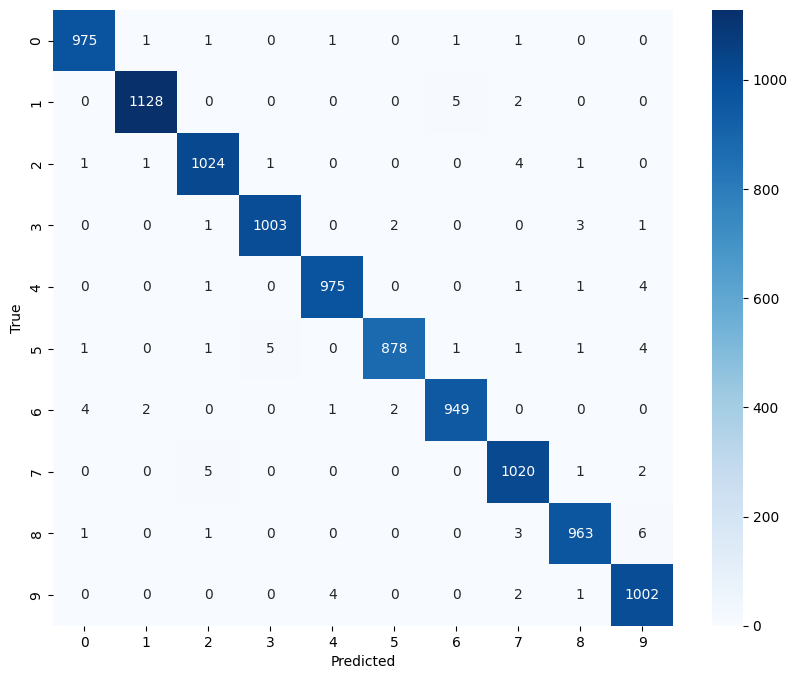

In [4]:
from tensorflow.keras import backend as K
from sklearn.metrics import classification_report
# Generate predictions
y_pred_prob = model.predict(X_test)
y_pred = y_pred_prob.argmax(axis=1) # Get class predictions
# Classification report for precision, recall, and F1-score
print("Classification Report:")
print(classification_report(y_test, y_pred))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Predict the labels for the test set
y_pred = np.argmax(model.predict(X_test), axis=-1)
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()